In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
file_path = "credit_risk_dataset.csv"

df = pd.read_csv(file_path)

In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
df.shape

(32581, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [ ]:
df.duplicated().sum()

np.int64(165)

In [ ]:
df = df.drop_duplicates()

In [ ]:
numeric_columns = df.select_dtypes(include=["int64","float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

In [ ]:
# Fill missing numeric values with median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
target = "loan_status"
df[target].value_counts()

,count
loan_status,
0,25327
1,7089


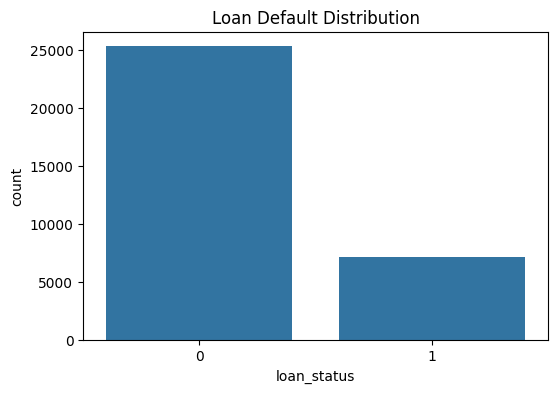

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df)
plt.title("Loan Default Distribution")
plt.show()

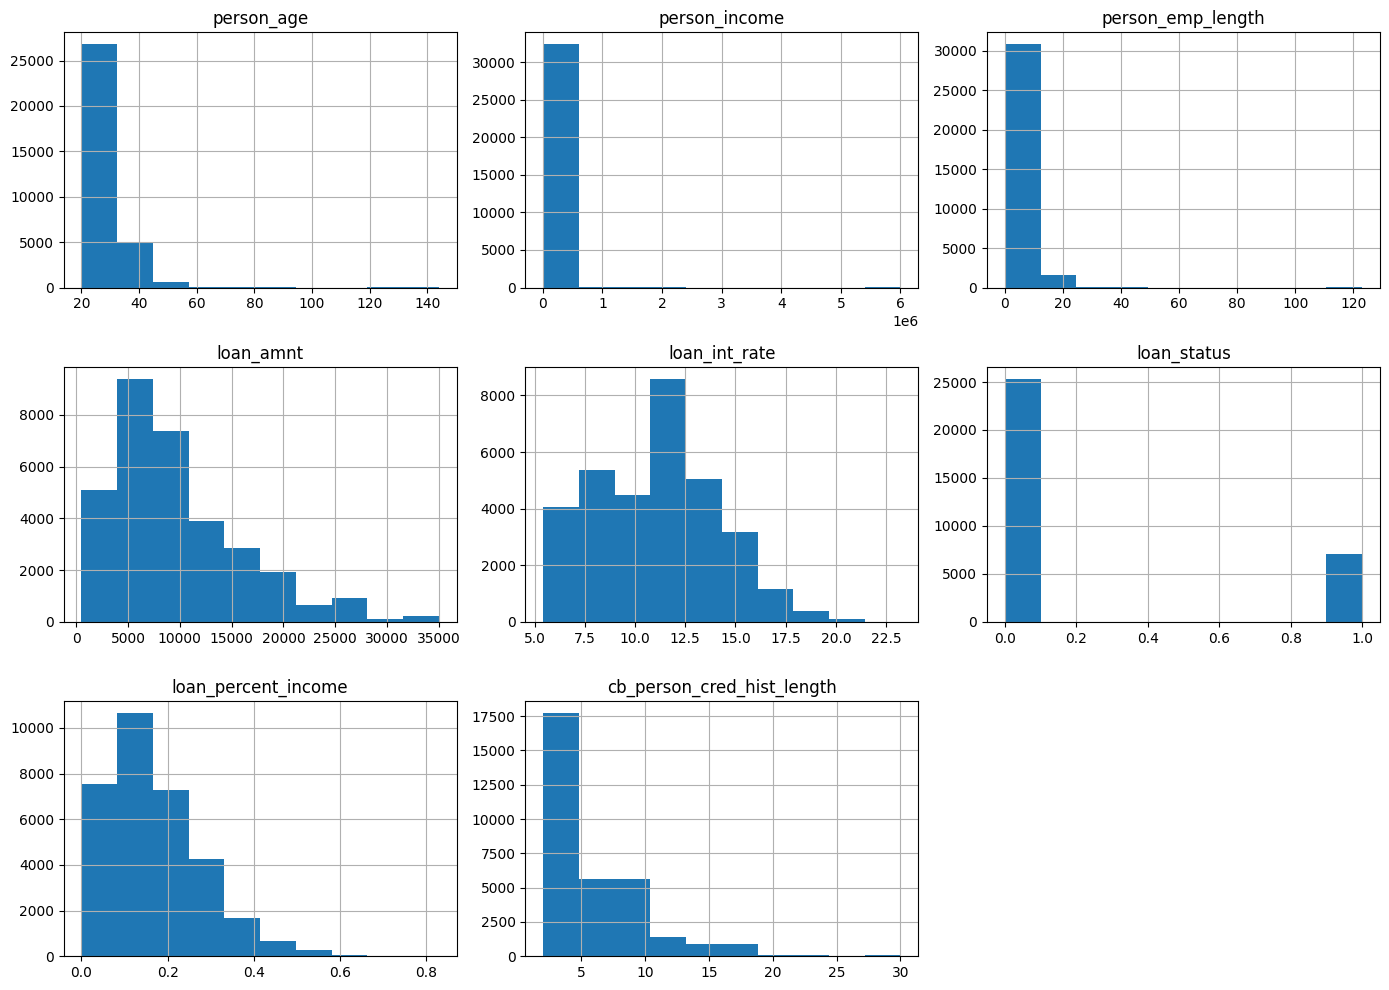

In [ ]:
df[numeric_columns].hist(figsize=(14,10))
plt.tight_layout()
plt.show()

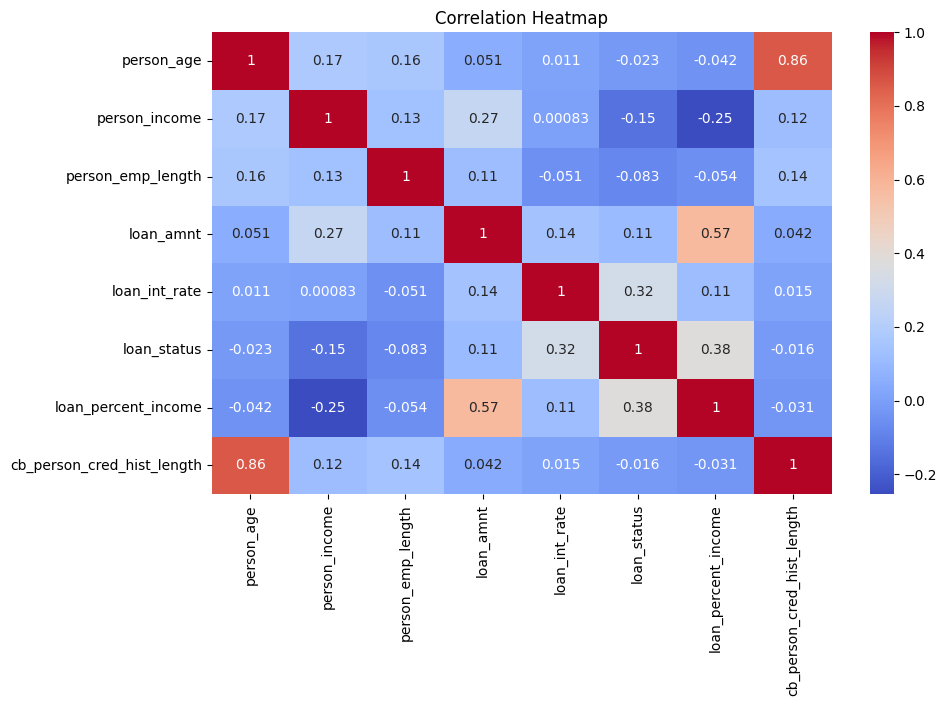

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_columns].corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

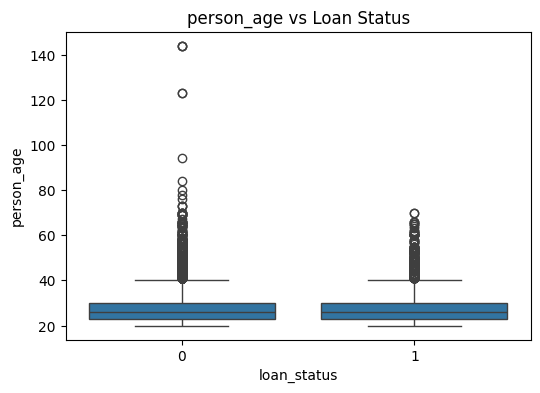

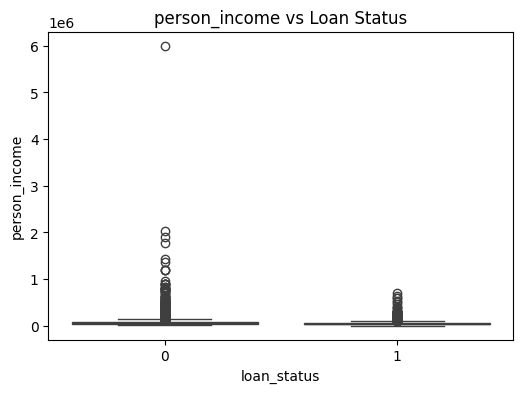

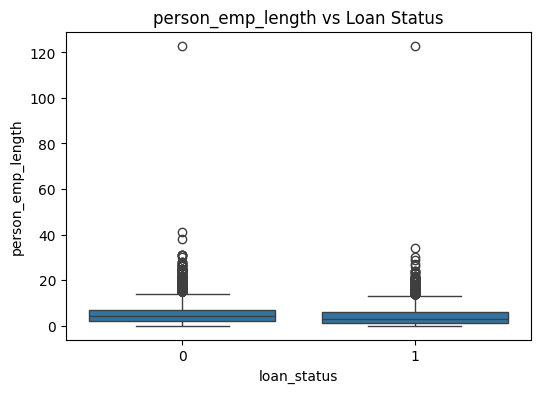

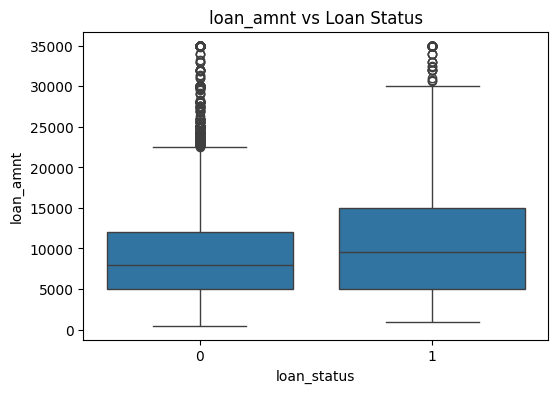

In [ ]:
sample_features = [col for col in numeric_columns if col != target][:4]

for feature in sample_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target, y=feature, data=df)
    plt.title(f"{feature} vs Loan Status")
    plt.show()

In [ ]:
X = df.drop(columns=[target])
y = df[target]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,False,False,True,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0.10,2,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,False,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,0.53,2,False,False,True,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,0.55,4,False,False,True,...,True,False,False,False,True,False,False,False,False,True


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.shape, X_test.shape

((25932, 22), (6484, 22))

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[4829,  237],
       [ 765,  653]])

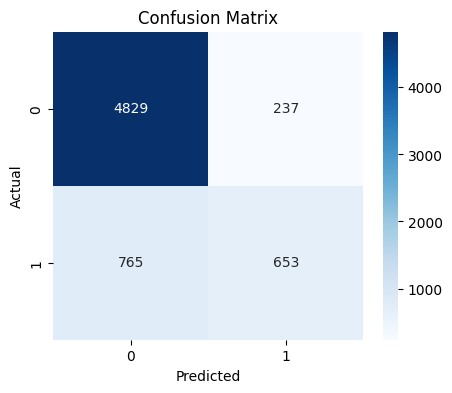

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.95      0.91      5066
           1       0.73      0.46      0.57      1418

    accuracy                           0.85      6484
   macro avg       0.80      0.71      0.74      6484
weighted avg       0.83      0.85      0.83      6484



In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8471958581143574


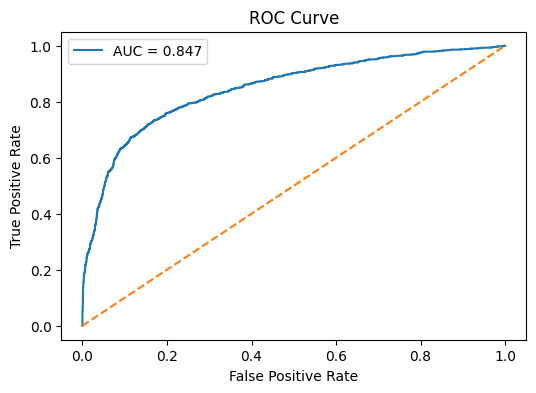

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["abs_coef"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values("abs_coef", ascending=False)

coefficients.head(10)

,Feature,Coefficient,abs_coef
17,loan_grade_D,1.180140,1.180140
8,person_home_ownership_OWN,-1.123707,1.123707
14,loan_intent_VENTURE,-0.999591,0.999591
16,loan_grade_C,-0.908334,0.908334
18,loan_grade_E,0.825918,0.825918
9,person_home_ownership_RENT,0.767808,0.767808
10,loan_intent_EDUCATION,-0.764451,0.764451
13,loan_intent_PERSONAL,-0.602427,0.602427
5,loan_percent_income,0.519366,0.519366
11,loan_intent_HOMEIMPROVEMENT,0.515190,0.515190


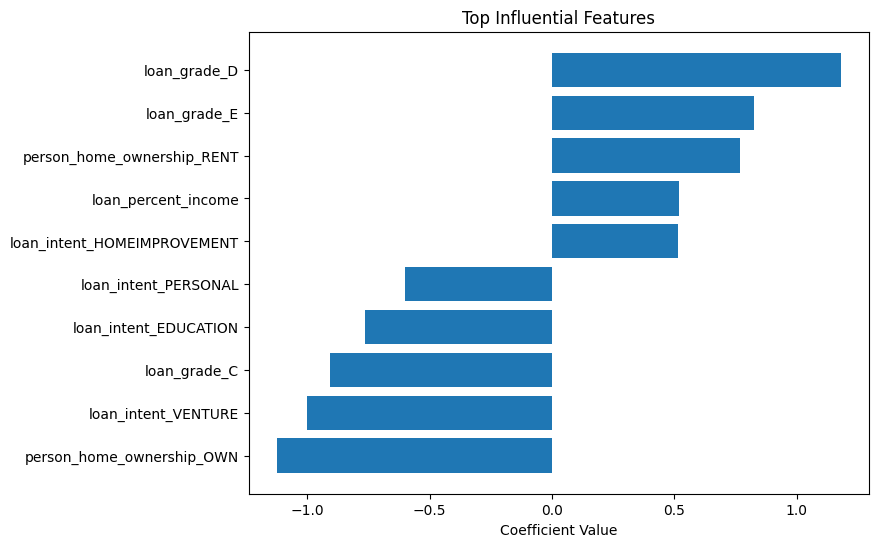

In [ ]:
top_features = coefficients.head(10).sort_values("Coefficient")

plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top Influential Features")
plt.xlabel("Coefficient Value")
plt.show()

In [ ]:
summary = """
Project: Credit Risk / Loan Default Prediction

Goal:
Predict whether a borrower is likely to default on a loan.

Workflow:
1. Data loading
2. Data overview
3. Data cleaning
4. Exploratory Data Analysis
5. Feature encoding
6. Train-test split
7. Logistic Regression training
8. Model evaluation
9. Feature interpretation

Model:
Logistic Regression

Evaluation Metrics:
- Accuracy
- Confusion Matrix
- ROC Curve
- ROC-AUC Score

Conclusion:
The logistic regression model provides a baseline for predicting loan default risk.
Important features identified by model coefficients can help explain risk factors.
"""

print(summary)


Project: Credit Risk / Loan Default Prediction

Goal:
Predict whether a borrower is likely to default on a loan.

Workflow:
1. Data loading
2. Data overview
3. Data cleaning
4. Exploratory Data Analysis
5. Feature encoding
6. Train-test split
7. Logistic Regression training
8. Model evaluation
9. Feature interpretation

Model:
Logistic Regression

Evaluation Metrics:
- Accuracy
- Confusion Matrix
- ROC Curve
- ROC-AUC Score

Conclusion:
The logistic regression model provides a baseline for predicting loan default risk.
Important features identified by model coefficients can help explain risk factors.

